In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load the data
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0)

# Clean any missing dates or headlines immediately
df.dropna(subset=['date', 'headline'], inplace=True)

print("Data Loaded successfully!")
df.head()

Data Loaded successfully!


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


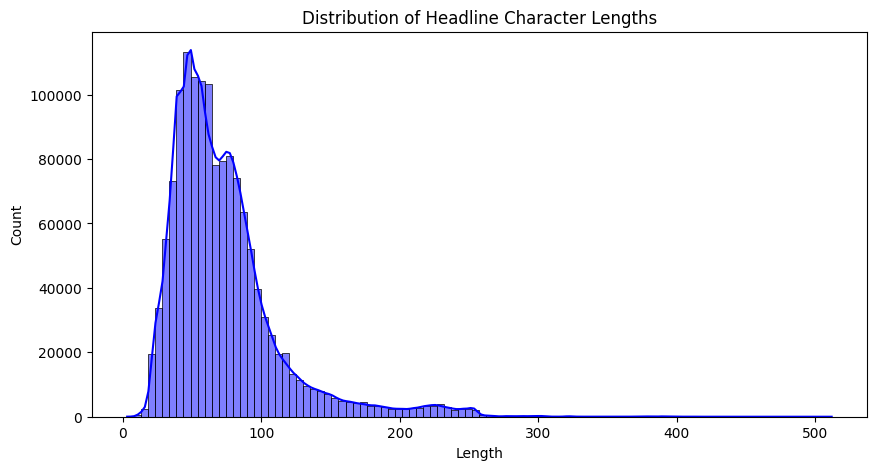

In [4]:
# Calculate headline lengths
df['headline_len'] = df['headline'].apply(len)

print("Headline Length Statistics:")
print(df['headline_len'].describe())

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['headline_len'], bins=100, kde=True, color='blue')
plt.title('Distribution of Headline Character Lengths')
plt.xlabel('Length')
plt.show()

Top 10 Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


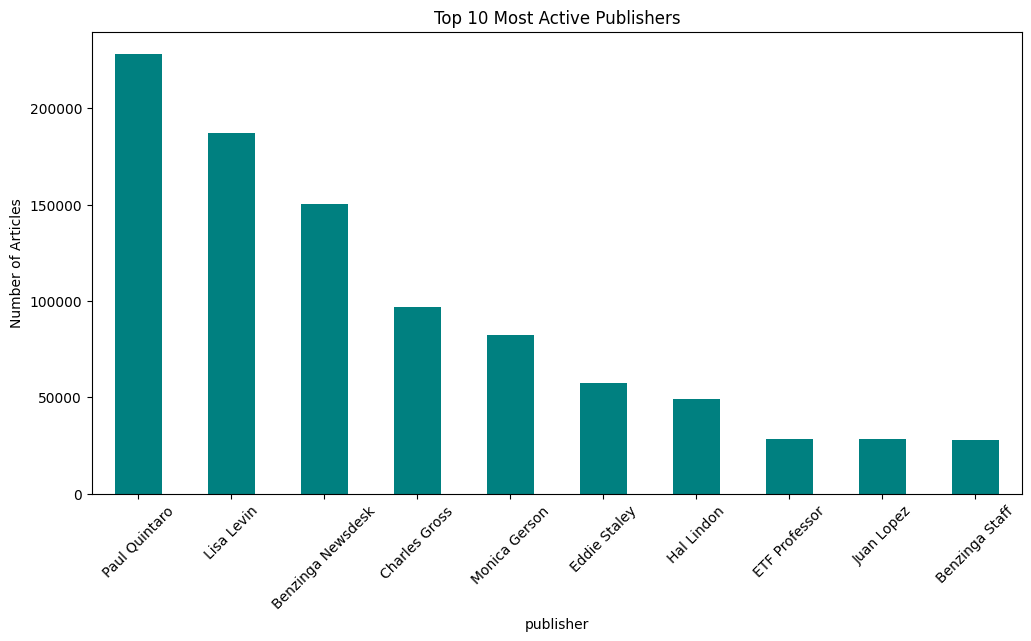

In [5]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts()

print("Top 10 Publishers:")
print(publisher_counts.head(10))

# Plot Top 10
plt.figure(figsize=(12, 6))
publisher_counts.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Most Active Publishers')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

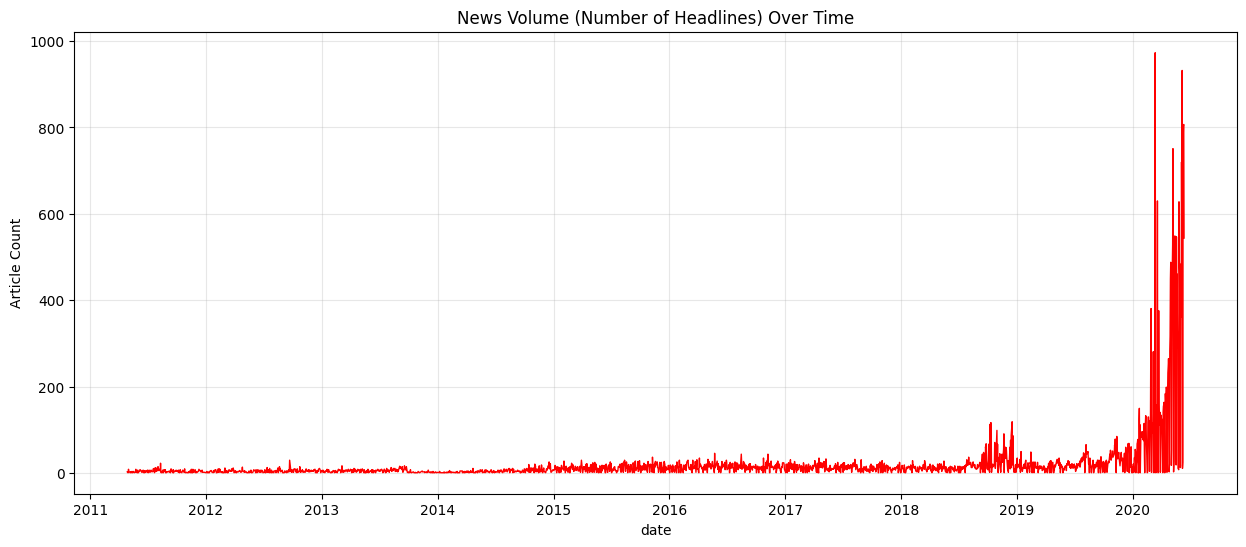

In [6]:
# Convert 'date' column to datetime
# Note: NASA and financial data often have extra timezone info, 
# errors='coerce' handles weird formats.
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)

# Group by day to see news volume
daily_news = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15, 6))
daily_news.plot(color='red', linewidth=1)
plt.title('News Volume (Number of Headlines) Over Time')
plt.ylabel('Article Count')
plt.grid(True, alpha=0.3)
plt.show()

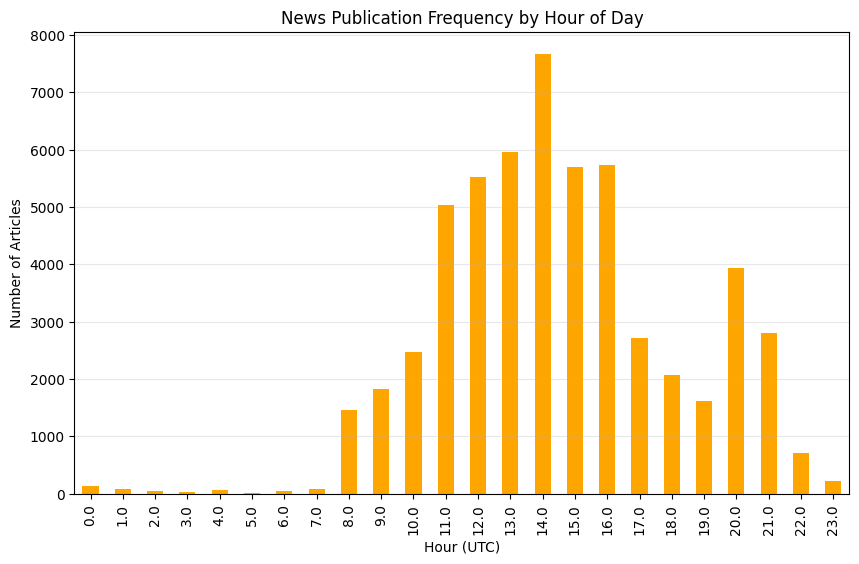

In [7]:
# Extract hour from the date
df['hour'] = df['date'].dt.hour

# Plot news volume by hour
plt.figure(figsize=(10, 6))
df['hour'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('News Publication Frequency by Hour of Day')
plt.xlabel('Hour (UTC)')
plt.ylabel('Number of Articles')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [8]:
from collections import Counter
import re

# Simple function to clean and tokenize headlines
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text.split()

# Count words (caution: this takes a few seconds for 1.4M rows)
all_words = Counter()
df['headline'].dropna().apply(lambda x: all_words.update(clean_text(x)))

# Show top 20 most common words
print("Most Common Words in Headlines:")
for word, count in all_words.most_common(20):
    print(f"{word}: {count}")

Most Common Words in Headlines:
to: 402875
of: 269807
on: 245071
for: 238895
in: 220556
the: 212758
vs: 162061
stocks: 161868
est: 140578
eps: 128910
from: 120708
shares: 114182
and: 113434
reports: 108705
update: 91680
market: 90879
earnings: 87185
with: 84203
sales: 79524
top: 78648


In [9]:
# Check if any publishers contain an '@' symbol
emails = df[df['publisher'].str.contains('@', na=False)]['publisher'].unique()
print(f"Found {len(emails)} publishers that look like emails.")

# If emails exist, extract the domain
if len(emails) > 0:
    df['publisher_domain'] = df['publisher'].apply(lambda x: x.split('@')[-1] if '@' in str(x) else x)
    print("\nTop Domains:")
    print(df['publisher_domain'].value_counts().head(10))

Found 18 publishers that look like emails.

Top Domains:
publisher_domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [10]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Filter the counter we created in the previous step
filtered_words = Counter({k: v for k, v in all_words.items() if k not in stop_words and len(k) > 2})

print("Significant Financial Topics/Keywords:")
for word, count in filtered_words.most_common(20):
    print(f"{word}: {count}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Johnny_Messay\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Significant Financial Topics/Keywords:
stocks: 161868
est: 140578
eps: 128910
shares: 114182
reports: 108705
update: 91680
market: 90879
earnings: 87185
sales: 79524
top: 78648
announces: 66528
price: 64231
buy: 64059
downgrades: 61942
trading: 61156
benzingas: 57985
raises: 57798
upgrades: 56804
target: 54616
maintains: 52961
